# Install

## Tati (modificar archivo correspondiente)

/usr/local/lib/python3.10/dist-packages/torch_geometric_temporal/nn/attention/tsagcn.py


In [1]:
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.4.0+cu121.html
!pip install torch-geometric
!pip install torch-geometric-temporal

Looking in links: https://data.pyg.org/whl/torch-2.4.0+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 12.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 16.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 17.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 20.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 986.2/986.2 kB 20.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 70.8 MB/s eta 0:00:00
  Created wheel for torch-geometric-temporal: filename=torch_geometric_temporal-0.54.0-py3-none-any.whl size=86709 sha256=959750d2c7b0e91a27c7e4d5342e7a31c507a8d031404705f6459d

**NOTE:** Line 6 of /usr/local/lib/python3.10/dist-packages/torch_geometric_temporal/nn/attention/tsagcn.py should be modified (add an underscore), like this:

`from torch_geometric.utils._to_dense_adj import to_dense_adj`

In [2]:
!pip install networkx
#!pip install sklearn

# Data - Preprocess

Data downloaded in csv from https://research.unsw.edu.au/projects/unsw-nb15-dataset

## UNSW-NB15_1

### Dataset UNSW-NB15 - Descripción de Características

| N° | Característica | Tipo | Descripción |
|----|----------------|------|-------------|
| 1 | srcip | nominal | Dirección IP de origen |
| 2 | sport | integer | Número de puerto de origen |
| 3 | dstip | nominal | Dirección IP de destino |
| 4 | dsport | integer | Número de puerto de destino |
| 5 | proto | nominal | Protocolo de transacción |
| 6 | state | nominal | Estado y protocolo dependiente (ACC, CLO, CON, ECO, ECR, FIN, INT, MAS, PAR,...) |
| 7 | dur | float | Duración total del registro |
| 8 | sbytes | integer | Bytes de transacción origen a destino |
| 9 | dbytes | integer | Bytes de transacción destino a origen |
| 10 | sttl | integer | Valor time to live origen a destino |
| 11 | dttl | integer | Valor time to live destino a origen |
| 12 | sloss | integer | Paquetes retransmitidos o perdidos en origen |
| 13 | dloss | integer | Paquetes retransmitidos o perdidos en destino |
| 14 | service | nominal | Servicios (http, ftp, smtp, ssh, dns, ftp-data, irc, (-) si no es común) |
| 15 | sload | float | Bits por segundo de origen |
| 16 | dload | float | Bits por segundo de destino |
| 17 | spkts | integer | Conteo de paquetes origen a destino |
| 18 | dpkts | integer | Conteo de paquetes destino a origen |
| 19 | swin | integer | Valor de ventana TCP de origen |
| 20 | dwin | integer | Valor de ventana TCP de destino |
| 21 | stcpb | integer | Número de secuencia base TCP de origen |
| 22 | dtcpb | integer | Número de secuencia base TCP de destino |
| 23 | smeansz | integer | Tamaño medio de paquete transmitido por origen |
| 24 | dmeansz | integer | Tamaño medio de paquete transmitido por destino |
| 25 | trans_depth | integer | Profundidad de transacción http request/response |
| 26 | res_bdy_len | integer | Tamaño real del contenido transferido desde el servidor http |
| 27 | sjit | float | Jitter de origen (mSec) |
| 28 | djit | float | Jitter de destino (mSec) |
| 29 | stime | timestamp | Tiempo de inicio del registro |
| 30 | ltime | timestamp | Último tiempo del registro |
| 31 | sintpkt | float | Tiempo entre llegadas de paquetes de origen (mSec) |
| 32 | dintpkt | float | Tiempo entre llegadas de paquetes de destino (mSec) |
| 33 | tcprtt | float | Tiempo round-trip de conexión TCP |
| 34 | synack | float | Tiempo entre paquetes SYN y SYN_ACK |
| 35 | ackdat | float | Tiempo entre paquetes SYN_ACK y ACK |
| 36 | is_sm_ips_ports | binary | 1 si IPs y puertos origen/destino son iguales |
| 37 | ct_state_ttl | integer | Número de estados según rango de TTL |
| 38 | ct_flw_http_mthd | integer | Número de flujos con métodos Get/Post en servicio http |
| 39 | is_ftp_login | binary | 1 si sesión ftp accedida con usuario/contraseña |
| 40 | ct_ftp_cmd | integer | Número de flujos con comandos en sesión ftp |
| 41 | ct_srv_src | integer | Conexiones con mismo servicio y dirección origen en 100 conexiones |
| 42 | ct_srv_dst | integer | Conexiones con mismo servicio y dirección destino en 100 conexiones |
| 43 | ct_dst_ltm | integer | Conexiones con misma dirección destino en 100 conexiones |
| 44 | ct_src_ltm | integer | Conexiones con misma dirección origen en 100 conexiones |
| 45 | ct_src_dport_ltm | integer | Conexiones con misma dirección origen y puerto destino en 100 conexiones |
| 46 | ct_dst_sport_ltm | integer | Conexiones con misma dirección destino y puerto origen en 100 conexiones |
| 47 | ct_dst_src_ltm | integer | Conexiones con mismas direcciones origen y destino en 100 conexiones |
| 48 | attack_cat | nominal | Categoría de ataque (Fuzzers, Analysis, Backdoor, etc.) |
| 49 | label | binary | 0 para normal, 1 para ataque |

### Read and explore

In [3]:
import pandas as pd

data_unsw1 = pd.read_csv('/content/UNSW-NB15_1.csv', low_memory=False)



In [4]:
# Rename columns
columnas = [
    "srcip", "sport", "dstip", "dsport", "proto", "state", "dur", "sbytes", "dbytes", "sttl",
    "dttl", "sloss", "dloss", "service", "sload", "dload", "spkts", "dpkts", "swin", "dwin",
    "stcpb", "dtcpb", "smeansz", "dmeansz", "trans_depth", "res_bdy_len", "sjit", "djit",
    "stime", "ltime", "sintpkt", "dintpkt", "tcprtt", "synack", "ackdat", "is_sm_ips_ports",
    "ct_state_ttl", "ct_flw_http_mthd", "is_ftp_login", "ct_ftp_cmd", "ct_srv_src", "ct_srv_dst",
    "ct_dst_ltm", "ct_src_ltm", "ct_src_dport_ltm", "ct_dst_sport_ltm", "ct_dst_src_ltm",
    "attack_cat", "label"
]

data_unsw1.columns = columnas


In [5]:
data_unsw1['dur'] = pd.to_numeric(data_unsw1['dur'], errors='coerce')

min_dur = data_unsw1['dur'].min()
max_dur = data_unsw1['dur'].max()
mean_dur = data_unsw1['dur'].mean()

print(f"Min dur: {pd.to_timedelta(min_dur, unit='s')}")
print(f"Max dur: {pd.to_timedelta(max_dur, unit='s')}")
print(f"Mean dur: {pd.to_timedelta(mean_dur, unit='s')}")


Min dur: 0 days 00:00:00
Max dur: 0 days 02:26:26.637695
Mean dur: 0 days 00:00:00.863392160


In [5]:
# Convert 'stime' and 'ltime' to datetime format
data_unsw1['stime'] = pd.to_datetime(data_unsw1['stime'], unit='s')
data_unsw1['ltime'] = pd.to_datetime(data_unsw1['ltime'], unit='s')

min_start_time = data_unsw1['stime'].min()
max_end_time = data_unsw1['ltime'].max()

print("Min start time:", min_start_time)
print("Max end time:", max_end_time)

# Filter connections lasting less than a second
filtered_unsw1 = data_unsw1[data_unsw1['dur'] <= 1]

Min start time: 2015-01-22 11:49:37
Max end time: 2015-01-22 19:44:02


In [22]:
import networkx as nx
from datetime import timedelta

min_start_time = data_unsw1['stime'].min()
max_end_time = data_unsw1['ltime'].max()

snapshots = []

# Define the time interval for each snapshot (10 minutes)
interval_snapshot = timedelta(minutes=10)

start_time = min_start_time
end_time = start_time + interval_snapshot

while start_time < max_end_time:
    # Filter connections that occur in the current interval
    snapshot_data = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)]
    #
    G_snapshot = nx.Graph()
    #
    for _, row in snapshot_data.iterrows():
        src_ip = row['srcip']
        dst_ip = row['dstip']
        row_start_time = row['stime']
        row_end_time = row['ltime']
        protocol = row['proto']
        duration = row['dur']
        sbytes = row['sbytes']
        dbytes = row['dbytes']
        label = row['label']
        # Add edge
        G_snapshot.add_edge(src_ip, dst_ip, **row.to_dict())
    #
    snapshots.append(G_snapshot)
    #
    start_time = end_time
    end_time = start_time + interval_snapshot


print("Number of snapshots:", len(snapshots))
print("Number of nodes in the first snapshot:", snapshots[0].number_of_nodes())
print("Number of edges in the first snapshot:", snapshots[0].number_of_edges())

Number of snapshots: 48
Number of nodes in the first snapshot: 37
Number of edges in the first snapshot: 143


In [28]:
print("Malicious connections that lasted less than one second:", len(data_unsw1[(data_unsw1["dur"]<=1) & (data_unsw1["label"]==1)]))
print("Malicious connections that lasted more than one second:", len(data_unsw1[(data_unsw1["dur"]>1) & (data_unsw1["label"]==1)]))

Malicious connections that lasted less than one second: 18183
Malicious connections that lasted more than one second: 4032


### Filter 2 hours (Tati)

In [29]:
for i, G_snapshot in enumerate(snapshots):
  suma_norm=0
  suma_bot=0
  labb=[data['label'] for _, _, data in G_snapshot.edges(data=True) if 'label' in data]
  for j in range(len(labb)):
    if labb[j]==0:
      suma_norm+=1
    else:
      suma_bot+=1
  print(i,suma_norm,suma_bot)

0 105 38
1 109 36
2 104 40
3 105 40
4 106 40
5 109 38
6 106 39
7 108 38
8 109 36
9 109 35
10 106 38
11 105 38
12 103 0
13 103 0
14 103 0
15 103 0
16 106 0
17 105 0
18 105 0
19 106 0
20 104 0
21 106 0
22 105 0
23 105 0
24 105 0
25 104 0
26 105 0
27 105 0
28 105 0
29 104 0
30 105 0
31 106 0
32 105 0
33 104 0
34 106 0
35 106 0
36 105 0
37 105 0
38 105 0
39 105 0
40 105 0
41 105 0
42 104 0
43 105 0
44 105 0
45 103 0
46 102 0
47 102 0


In [6]:
from datetime import timedelta

start_time = data_unsw1['stime'].min()
end_time = start_time + timedelta(minutes=120)

unsw1 = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)]

In [31]:
len(unsw1[unsw1["label"]==1])

18183

### Create snapshots every 3 minutes (Tati modified Rey's code)

In [34]:
import networkx as nx
from datetime import timedelta

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()

snapshots = []

# Define the time interval for each snapshot (3 minutes)
interval_snapshot = timedelta(minutes=3)

start_time = min_start_time
end_time = start_time + interval_snapshot

while start_time < max_end_time:
    # Filter connections that occur in the current interval
    snapshot_data = unsw1[(unsw1['stime'] >= start_time) & (unsw1['stime'] < end_time)]

    G_snapshot = nx.Graph()

    for _, row in snapshot_data.iterrows():
        src_ip = row['srcip']
        dst_ip = row['dstip']
        row_start_time = row['stime']
        row_end_time = row['ltime']
        protocol = row['proto']
        duration = row['dur']
        sbytes = row['sbytes']
        dbytes = row['dbytes']
        label = row['label']
        # Add edge
        G_snapshot.add_edge(src_ip, dst_ip, **row.to_dict())

    snapshots.append(G_snapshot)

    start_time = end_time
    end_time = start_time + interval_snapshot

print("Number of snapshots:", len(snapshots))
print("Number of nodes in the first snapshot:", snapshots[0].number_of_nodes())
print("Number of edges in the first snapshot:", snapshots[0].number_of_edges())


Number of snapshots: 40
Number of nodes in the first snapshot: 37
Number of edges in the first snapshot: 142


In [35]:
for i, G_snapshot in enumerate(snapshots):
  suma_norm=0
  suma_bot=0
  labb=[data['label'] for _, _, data in G_snapshot.edges(data=True) if 'label' in data]
  for j in range(len(labb)):
    if labb[j]==0:
      suma_norm+=1
    else:
      suma_bot+=1
  print(i,suma_norm,suma_bot)

0 103 39
1 104 37
2 105 36
3 105 24
4 104 33
5 106 32
6 107 36
7 108 35
8 104 38
9 103 38
10 105 36
11 104 38
12 104 39
13 107 38
14 106 38
15 108 37
16 107 37
17 108 37
18 108 37
19 107 38
20 107 35
21 108 33
22 108 32
23 108 34
24 109 35
25 106 36
26 107 36
27 104 36
28 104 37
29 108 34
30 104 36
31 107 32
32 110 26
33 108 33
34 105 36
35 106 35
36 103 37
37 105 36
38 104 39
39 104 0


## UNSW-NB15_2

In [7]:
data_unsw2 = pd.read_csv('/content/UNSW-NB15_2.csv', low_memory=False)
data_unsw2.columns = columnas


In [38]:
data_unsw2['dur'] = pd.to_numeric(data_unsw2['dur'], errors='coerce')

print(f"Min dur: {pd.to_timedelta(data_unsw2['dur'].min(), unit='s')}")
print(f"Max dur: {pd.to_timedelta(data_unsw2['dur'].max(), unit='s')}")
print(f"Mean dur: {pd.to_timedelta(data_unsw2['dur'].mean(), unit='s')}")

Min dur: 0 days 00:00:00
Max dur: 0 days 00:00:59.999989
Mean dur: 0 days 00:00:00.583991089


In [39]:
len(data_unsw2)

700000

In [8]:
data_unsw2['stime'] = pd.to_datetime(data_unsw2['stime'], unit='s')
data_unsw2['ltime'] = pd.to_datetime(data_unsw2['ltime'], unit='s')

print("Min start time:", data_unsw2['stime'].min())
print("Max end time:", data_unsw2['ltime'].max())

# Filter connections lasting less than a second
filtered_unsw2 = data_unsw2[data_unsw2['dur'] <= 1]


Min start time: 2015-01-22 19:43:15
Max end time: 2015-02-18 03:45:29


In [41]:
import networkx as nx
from datetime import timedelta

min_start_time = data_unsw2['stime'].min()
max_end_time = data_unsw2['ltime'].max()

snapshots = []

interval_snapshot = timedelta(minutes=60)

start_time = min_start_time
end_time = start_time + interval_snapshot

# i=0
while start_time < max_end_time:
    #if i==628 or i==632:
    #  print(i,inicio_tiempo)

    snapshot_data = filtered_unsw2[(filtered_unsw2['stime'] >= start_time) & (filtered_unsw2['stime'] < end_time)]

    G_snapshot = nx.Graph()

    for _, row in snapshot_data.iterrows():
        src_ip = row['srcip']
        dst_ip = row['dstip']
        row_start_time = row['stime']
        row_end_time = row['ltime']
        protocol = row['proto']
        duration = row['dur']
        sbytes = row['sbytes']
        dbytes = row['dbytes']
        label = row['label']
        # Add edge
        G_snapshot.add_edge(src_ip, dst_ip, **row.to_dict())

    snapshots.append(G_snapshot)

    start_time = end_time
    end_time = start_time + interval_snapshot
    #i+=1

print("Number of snapshots:", len(snapshots))
print("Number of nodes in the first snapshot:", snapshots[0].number_of_nodes())
print("Number of edges in the first snapshot:", snapshots[0].number_of_edges())

Number of snapshots: 633
Number of nodes in the first snapshot: 26
Number of edges in the first snapshot: 106


In [42]:
for i, G_snapshot in enumerate(snapshots):
  suma_norm=0
  suma_bot=0
  labb=[data['label'] for _, _, data in G_snapshot.edges(data=True) if 'label' in data]
  for j in range(len(labb)):
    if labb[j]==0:
      suma_norm+=1
    else:
      suma_bot+=1
  print(i,suma_norm,suma_bot)

0 106 0
1 106 0
2 106 0
3 106 0
4 106 0
5 0 0
6 0 0
7 0 0
8 0 0
9 0 0
10 0 0
11 0 0
12 0 0
13 0 0
14 0 0
15 0 0
16 0 0
17 0 0
18 0 0
19 0 0
20 0 0
21 0 0
22 0 0
23 0 0
24 0 0
25 0 0
26 0 0
27 0 0
28 0 0
29 0 0
30 0 0
31 0 0
32 0 0
33 0 0
34 0 0
35 0 0
36 0 0
37 0 0
38 0 0
39 0 0
40 0 0
41 0 0
42 0 0
43 0 0
44 0 0
45 0 0
46 0 0
47 0 0
48 0 0
49 0 0
50 0 0
51 0 0
52 0 0
53 0 0
54 0 0
55 0 0
56 0 0
57 0 0
58 0 0
59 0 0
60 0 0
61 0 0
62 0 0
63 0 0
64 0 0
65 0 0
66 0 0
67 0 0
68 0 0
69 0 0
70 0 0
71 0 0
72 0 0
73 0 0
74 0 0
75 0 0
76 0 0
77 0 0
78 0 0
79 0 0
80 0 0
81 0 0
82 0 0
83 0 0
84 0 0
85 0 0
86 0 0
87 0 0
88 0 0
89 0 0
90 0 0
91 0 0
92 0 0
93 0 0
94 0 0
95 0 0
96 0 0
97 0 0
98 0 0
99 0 0
100 0 0
101 0 0
102 0 0
103 0 0
104 0 0
105 0 0
106 0 0
107 0 0
108 0 0
109 0 0
110 0 0
111 0 0
112 0 0
113 0 0
114 0 0
115 0 0
116 0 0
117 0 0
118 0 0
119 0 0
120 0 0
121 0 0
122 0 0
123 0 0
124 0 0
125 0 0
126 0 0
127 0 0
128 0 0
129 0 0
130 0 0
131 0 0
132 0 0
133 0 0
134 0 0
135 0 0
136 0 0
137 

In [9]:
from datetime import timedelta

start_time = data_unsw2['stime'].min() + timedelta(minutes=628*60)
end_time = start_time + timedelta(minutes=4*60)

unsw2 = filtered_unsw2[(filtered_unsw2['stime'] >= start_time) & (filtered_unsw2['stime'] < end_time)]


In [44]:
import networkx as nx
from datetime import timedelta

min_start_time = unsw2['stime'].min()
max_end_time = unsw2['ltime'].max()

# Crear una lista para almacenar los snapshots
snapshots = []

interval_snapshot = timedelta(minutes=60)

start_time = unsw2['stime'].min()
end_time = start_time + interval_snapshot

while start_time < max_end_time:
    snapshot_data = unsw2[(unsw2['stime'] >= start_time) & (unsw2['stime'] < end_time)]

    G_snapshot = nx.Graph()

    for _, row in snapshot_data.iterrows():
        src_ip = row['srcip']
        dst_ip = row['dstip']
        row_start_time = row['stime']
        row_end_time = row['ltime']
        protocol = row['proto']
        duration = row['dur']
        sbytes = row['sbytes']
        dbytes = row['dbytes']
        label = row['label']
        # Add edge
        G_snapshot.add_edge(src_ip, dst_ip, **row.to_dict())

    snapshots.append(G_snapshot)

    start_time = end_time
    end_time = start_time + interval_snapshot

print("Number of snapshots:", len(snapshots))
print("Number of nodes in the first snapshot:", snapshots[0].number_of_nodes())
print("Number of edges in the first snapshot:", snapshots[0].number_of_edges())

Number of snapshots: 4
Number of nodes in the first snapshot: 44
Number of edges in the first snapshot: 150


In [45]:
for i, G_snapshot in enumerate(snapshots):
  suma_norm=0
  suma_bot=0
  labb=[data['label'] for _, _, data in G_snapshot.edges(data=True) if 'label' in data]
  for j in range(len(labb)):
    if labb[j]==0:
      suma_norm+=1
    else:
      suma_bot+=1
  print(i,suma_norm,suma_bot)

0 111 39
1 115 39
2 112 39
3 109 38


# Final Data

## Final UNSW_NB15_1

In [10]:
import torch
import networkx as nx
from torch_geometric_temporal.signal import DynamicGraphTemporalSignal
from datetime import timedelta


# Get all unique IPs from srcip and dstip
unique_ips = pd.unique(unsw1[['srcip', 'dstip']].values.ravel('K'))

# Create a mapping from IP address to a unique node index
ip_to_index = {ip: idx for idx, ip in enumerate(unique_ips)}


edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()

interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time + interval_snapshot


# Crear los snapshots
while start_time < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time) & (unsw1['stime'] < end_time)]

    edge_attr = snapshot_data.groupby(['srcip', 'dstip']).agg({
        'dur': 'mean',
        'sbytes': 'mean',
        'dbytes': 'mean',
        'spkts': 'mean',
        'dpkts': 'mean',
        'label': 'max'
    }).reset_index()
    edge_index = torch.tensor([[ip_to_index[src], ip_to_index[dst]] for src, dst in zip(edge_attr['srcip'], edge_attr['dstip'])], dtype=torch.long).t().contiguous()
    edge_features_tensor = torch.tensor(edge_attr[['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    node_features.append(torch.ones(len(unique_ips), dtype=torch.float))

    start_time = end_time
    end_time += interval_snapshot


# Crear el objeto DynamicGraphTemporalSignal con los datos recolectados
dataset_unsw1 = DynamicGraphTemporalSignal(
    edge_indices=edge_indices,
    edge_features=edge_features,
    edge_weights=edge_weights,
    features=node_features,
    targets=labels
)

In [11]:
node_features_pad = torch.zeros(len(unique_ips), 1, dtype=torch.float)

In [12]:
from torch_geometric.data import Data

torch_geo_graphs_unsw1 = {i: Data(x=node_features_pad, edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

## Final UNSW_NB15_2

In [13]:
import torch
import networkx as nx
from torch_geometric_temporal.signal import DynamicGraphTemporalSignal
from datetime import timedelta


# Get all unique IPs from srcip and dstip
unique_ips = pd.unique(unsw2[['srcip', 'dstip']].values.ravel('K'))

# Create a mapping from IP address to a unique node index
ip_to_index = {ip: idx for idx, ip in enumerate(unique_ips)}

edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw2['stime'].min()
max_end_time = unsw2['ltime'].max()


interval_snapshot = timedelta(minutes=60)
start_time = min_start_time
end_time = start_time  + interval_snapshot


while start_time  < max_end_time:
    snapshot_data = unsw2[(unsw2['stime'] >= start_time ) & (unsw2['stime'] < end_time)]

    edge_attr = snapshot_data.groupby(['srcip', 'dstip']).agg({
        'dur': 'mean',
        'sbytes': 'mean',
        'dbytes': 'mean',
        'spkts': 'mean',
        'dpkts': 'mean',
        'label': 'max'
    }).reset_index()
    edge_index = torch.tensor([[ip_to_index[src], ip_to_index[dst]] for src, dst in zip(edge_attr['srcip'], edge_attr['dstip'])], dtype=torch.long).t().contiguous()
    edge_features_tensor = torch.tensor(edge_attr[['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    node_features.append(torch.ones(len(unique_ips), dtype=torch.float))

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


# Crear el objeto DynamicGraphTemporalSignal con los datos recolectados
dataset_unsw2 = DynamicGraphTemporalSignal(
    edge_indices=edge_indices,
    edge_features=edge_features,
    edge_weights=edge_weights,
    features=node_features,
    targets=labels
)

In [14]:
node_features_pad = torch.zeros(len(unique_ips), 1, dtype=torch.float)

In [15]:
from torch_geometric.data import Data

torch_geo_graphs_unsw2 = {i: Data(x=node_features_pad, edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices))}

# Models

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [17]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from torch_geometric.nn import GCNConv, SAGEConv


class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, edge_attr_dim):
        super(GCN, self).__init__()
        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.conv2 = SAGEConv( hidden_dim, output_dim)
        #self.conv1 = GCNConv(input_dim, hidden_dim)
        #self.conv2 = GCNConv(hidden_dim, output_dim)
        self.fc = torch.nn.Linear(output_dim * 2 + edge_attr_dim, 1)  # Combine both nodes + edge_attr

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        x = self.conv1(x, edge_index)
        x = self.conv2(x, edge_index)

        # Combine node representations with edge features
        src_nodes = edge_index[0]  # Source nodes of edges
        dst_nodes = edge_index[1]  # Destination nodes of edges
        edge_features = torch.cat([x[src_nodes], x[dst_nodes], edge_attr], dim=1)

        return self.fc(edge_features)





In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, MessagePassing

# Definición del modelo recurrente para snapshots de grafos
class GraphRNN(nn.Module):
    def __init__(self, node_feature_dim, edge_feature_dim, hidden_dim):
        super(GraphRNN, self).__init__()
        self.node_feature_dim = node_feature_dim
        self.edge_feature_dim = edge_feature_dim
        self.hidden_dim = hidden_dim

        # Capas de convolución sobre el grafo para extraer características
        self.gcn1 = GCNConv(node_feature_dim, hidden_dim)
        self.gcn2 = GCNConv(hidden_dim, hidden_dim)

        # Capa recurrente para capturar información temporal
        self.gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)

        # Clasificador de aristas
        self.edge_classifier = nn.Sequential(
            nn.Linear(2 * hidden_dim + edge_feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)  # 2 clases: benigna o maligna
        )

    def forward(self, snapshots):
        """
        snapshots: lista de tuplas (x, edge_index, edge_attr) para cada snapshot.
        """
        hidden_states = []  # Para almacenar estados ocultos entre snapshots
        edge_predictions = []  # Predicciones para las aristas de cada snapshot

        h = None  # Estado inicial de la GRU

        for snapshot in snapshots:
            x, edge_index, edge_attr = snapshot

            # Paso 1: Extraer características de nodos con GCN
            x = F.relu(self.gcn1(x, edge_index))
            x = self.gcn2(x, edge_index)

            # Paso 2: Procesar la secuencia con GRU
            x_mean = x.mean(dim=0, keepdim=True)  # Reducir dimensión para GRU
            if h is None:
                h = torch.zeros(1, x_mean.size(0), self.hidden_dim).to(x.device)
            _, h = self.gru(x_mean.unsqueeze(0), h)

            # Paso 3: Combinar características de nodos y aristas para clasificación
            row, col = edge_index
            node_pairs = torch.cat([x[row], x[col]], dim=1)
            edge_features = torch.cat([node_pairs, edge_attr], dim=1)

            edge_logits = self.edge_classifier(edge_features)
            edge_predictions.append(edge_logits)

            hidden_states.append(h)

        return edge_predictions, hidden_states


In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, MessagePassing
from torch_geometric.nn.conv import GATv2Conv  # GATv2: Atención basada en grafos

# Definición del modelo recurrente para snapshots de grafos
class GraphRNNWithAttention(nn.Module):
    def __init__(self, node_feature_dim, edge_feature_dim, hidden_dim):
        super(GraphRNNWithAttention, self).__init__()
        self.node_feature_dim = node_feature_dim
        self.edge_feature_dim = edge_feature_dim
        self.hidden_dim = hidden_dim

        # Capas de convolución sobre el grafo con atención
        self.gcn1 = GCNConv(node_feature_dim, hidden_dim)
        self.gcn2 = GCNConv(hidden_dim, hidden_dim)
        self.attention_layer = GATv2Conv(hidden_dim, hidden_dim, heads=1, concat=False)  # Atención

        # Capa recurrente para capturar información temporal
        self.gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)

        # Clasificador de aristas
        self.edge_classifier = nn.Sequential(
            nn.Linear(2 * hidden_dim + edge_feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)  # 2 clases: benigna o maligna
        )

    def forward(self, snapshots):
        """
        snapshots: lista de tuplas (x, edge_index, edge_attr) para cada snapshot.
        """
        hidden_states = []  # Para almacenar estados ocultos entre snapshots
        edge_predictions = []  # Predicciones para las aristas de cada snapshot

        h = None  # Estado inicial de la GRU

        for snapshot in snapshots:
            x, edge_index, edge_attr = snapshot

            # Paso 1: Extraer características de nodos con GCN
            x = F.relu(self.gcn1(x, edge_index))
            x = F.relu(self.gcn2(x, edge_index))

            # Paso 2: Aplicar la capa de atención
            x = self.attention_layer(x, edge_index)

            # Paso 3: Procesar la secuencia con GRU
            x_mean = x.mean(dim=0, keepdim=True)  # Reducir dimensión para GRU
            if h is None:
                h = torch.zeros(1, x_mean.size(0), self.hidden_dim).to(x.device)
            _, h = self.gru(x_mean.unsqueeze(0), h)

            # Paso 4: Combinar características de nodos y aristas para clasificación
            row, col = edge_index
            node_pairs = torch.cat([x[row], x[col]], dim=1)
            edge_features = torch.cat([node_pairs, edge_attr], dim=1)

            edge_logits = self.edge_classifier(edge_features)
            edge_predictions.append(edge_logits)

            hidden_states.append(h)

        return edge_predictions, hidden_states


# Train and test

## Model 1

In [19]:
model1 = GCN(input_dim=1, hidden_dim=32, output_dim=16, edge_attr_dim=5).to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.01)

ratio_neg_to_pos = 2.5
pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)


train_windows = list(range(30))
val_windows = list(range(30,39))


# Train
epochs = 75
train_losses = []
val_losses = []

for epoch in range(epochs):
    # ===== Training =====
    model1.train()
    epoch_loss = 0
    for window in train_windows:
        data = torch_geo_graphs_unsw1[window].to(device)
        optimizer.zero_grad()
        out = model1(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_loss = epoch_loss / len(train_windows)
    train_losses.append(train_loss)

    # ===== Validation =====
    model1.eval()
    val_loss = 0
    with torch.no_grad():
        for window in val_windows:
            data = torch_geo_graphs_unsw1[window].to(device)
            out = model1(data)
            loss = criterion(out.squeeze(), data.y.to(device).float())
            val_loss += loss.item()
    val_loss = val_loss / len(val_windows)
    val_losses.append(val_loss)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")


# print("====================================================")

# # Test
# model1.eval()
# all_preds, all_labels = [], []
# with torch.no_grad():
#     for window in test_windows:
#         data = torch_geo_graphs_unsw1[window].to(device)
#         out = model1(data)
#         probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
#         # Convert probabilities to binary predictions using a threshold
#         preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5
#         #preds = torch.sigmoid(out).cpu().numpy()
#         all_preds.extend(preds)
#         all_labels.extend(data.y.cpu().numpy())

# # Metrics
# roc_auc = roc_auc_score(all_labels, all_preds)
# accuracy = accuracy_score(all_labels, all_preds)
# precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)  # Use 'binary' for binary classification
# recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)
# f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)

# print(f"ROC-AUC: {roc_auc:.4f}")
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall: {recall:.4f}")
# print(f"F1: {f1:.4f}")


Epoch 1/75, Train Loss: 197.0459, Val Loss: 60.0290
Epoch 2/75, Train Loss: 39.9979, Val Loss: 18.7758
Epoch 3/75, Train Loss: 15.7949, Val Loss: 10.9627
Epoch 4/75, Train Loss: 10.3941, Val Loss: 7.9980
Epoch 5/75, Train Loss: 7.2726, Val Loss: 2.5209
Epoch 6/75, Train Loss: 8.9543, Val Loss: 13.1166
Epoch 7/75, Train Loss: 22.5849, Val Loss: 16.7081
Epoch 8/75, Train Loss: 22.4559, Val Loss: 9.8003
Epoch 9/75, Train Loss: 15.2432, Val Loss: 16.3521
Epoch 10/75, Train Loss: 17.2572, Val Loss: 21.0238
Epoch 11/75, Train Loss: 19.8589, Val Loss: 12.2393
Epoch 12/75, Train Loss: 20.9659, Val Loss: 13.9649
Epoch 13/75, Train Loss: 26.7038, Val Loss: 7.3354
Epoch 14/75, Train Loss: 13.6309, Val Loss: 21.6592
Epoch 15/75, Train Loss: 25.8510, Val Loss: 22.6331
Epoch 16/75, Train Loss: 15.5452, Val Loss: 19.1596
Epoch 17/75, Train Loss: 17.6141, Val Loss: 12.5011
Epoch 18/75, Train Loss: 11.4219, Val Loss: 15.6784
Epoch 19/75, Train Loss: 14.6768, Val Loss: 12.9467
Epoch 20/75, Train Loss: 1

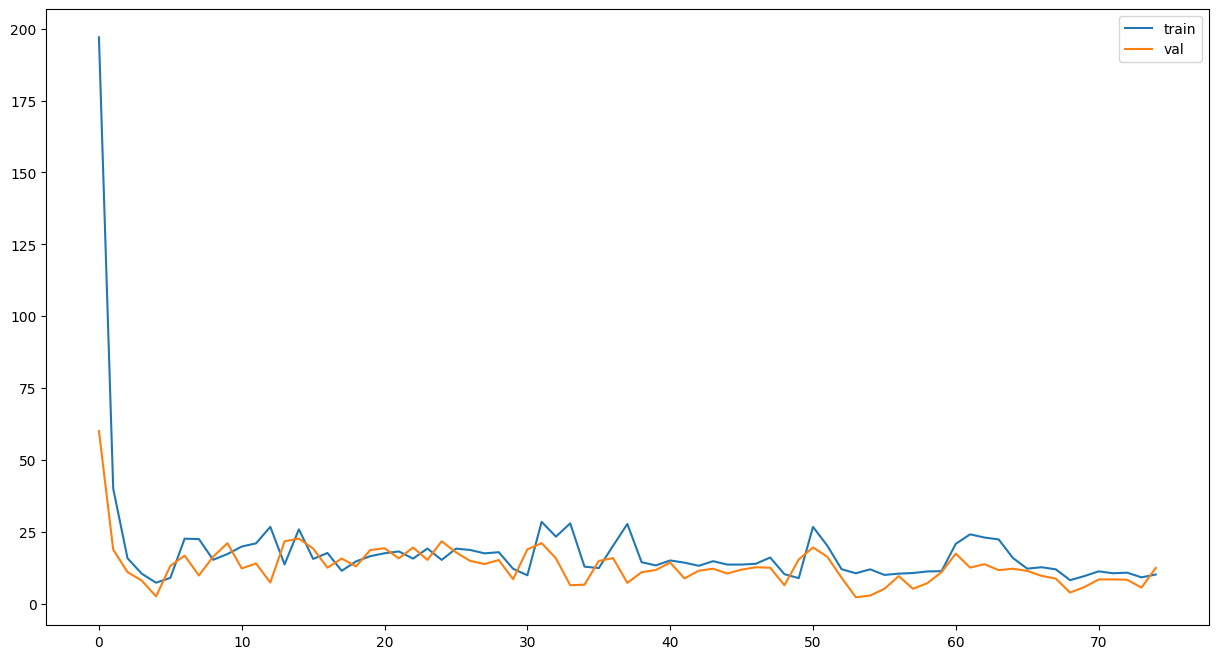

In [20]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(75), train_losses, label="train")
axs.plot(range(75), val_losses, label="val")
axs.legend()

In [21]:
# Evaluación UNSW_NB15_2
model1.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for window in range(len(torch_geo_graphs_unsw2)):
        data = torch_geo_graphs_unsw2[window].to(device)
        out = model1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds.extend(preds)
        all_labels.extend(data.y.cpu().numpy())

# Metrics
roc_auc = roc_auc_score(all_labels, all_preds)
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")


ROC-AUC: 0.5162
Accuracy: 0.3728
Precision: 0.2606
Recall: 0.8063
F1: 0.3939


## Model 2

In [33]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

#num_snapshots = 39
node_feature_dim = 1
edge_feature_dim = 5
hidden_dim = 16
batch_size = 2

train_windows = list(range(30))
val_windows = list(range(30,39))


model2 = GraphRNN(node_feature_dim, edge_feature_dim, hidden_dim)
optimizer = torch.optim.Adam(model2.parameters(), lr=0.01)
#loss_fn = nn.CrossEntropyLoss()

ratio_neg_to_pos = 2.5
pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Train
epochs = 200
train_losses = []
val_losses = []

for epoch in range(epochs):
    # ===== Training =====
    model2.train()
    total_loss = 0
    optimizer.zero_grad()

    snapshots_data = [(torch_geo_graphs_unsw1[i].x, torch_geo_graphs_unsw1[i].edge_index, torch_geo_graphs_unsw1[i].edge_attr) for i in train_windows]
    edge_labels = [torch_geo_graphs_unsw1[i].y for i in train_windows]

    edge_predictions, _ = model2(snapshots_data)

    # Calcular pérdida
    loss = sum(
        loss_fn(edge_pred.squeeze(), edge_label.float())
        for edge_pred, edge_label in zip(edge_predictions, edge_labels)
    )
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
    train_losses.append(total_loss)

    # ===== Validation =====
    model2.eval()
    val_loss = 0
    with torch.no_grad():
        val_snapshots_data = [(torch_geo_graphs_unsw1[i].x, torch_geo_graphs_unsw1[i].edge_index, torch_geo_graphs_unsw1[i].edge_attr) for i in val_windows]
        val_edge_labels = [torch_geo_graphs_unsw1[i].y for i in val_windows]

        val_edge_predictions, _ = model2(val_snapshots_data)

        val_loss = sum(
            loss_fn(edge_pred.squeeze(), edge_label.float())
            for edge_pred, edge_label in zip(val_edge_predictions, val_edge_labels)
        )
    val_losses.append(val_loss.item())

    # Mostrar métricas por época
    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {total_loss:.4f}, Val Loss: {val_loss:.4f}")


# print("========================================================")


# # Test
# model2.eval()
# all_preds, all_labels = [], []
# roc_auc = 0
# accuracy = 0
# precision = 0
# recall = 0
# f1 = 0
# with torch.no_grad():
#     snapshots_data_test = [(torch_geo_graphs_unsw1[i].x, torch_geo_graphs_unsw1[i].edge_index, torch_geo_graphs_unsw1[i].edge_attr) for i in test_windows]
#     edge_labels_test = [torch_geo_graphs_unsw1[i].y for i in test_windows]

#     edge_predictions, _ = model2(snapshots_data_test)

#     probabilities = [torch.sigmoid(edge_pred) for edge_pred in edge_predictions] # Apply sigmoid to get probabilities
#     # Convert probabilities to binary predictions using a threshold
#     preds = [(probabilities[i].view(-1) > 0.5).long() for i in range(len(probabilities))]  # Thresholding at 0.5
#     #preds = torch.sigmoid(out).cpu().numpy()
#     all_preds.extend(preds)
#     all_labels.extend(edge_labels_test)#data.y.cpu().numpy())

# # Metrics
# for i in range(len(all_preds)):
#     roc_auc += roc_auc_score(all_labels[i], all_preds[i])
#     accuracy += accuracy_score(all_labels[i], all_preds[i])
#     precision += precision_score(all_labels[i], all_preds[i], average='binary', zero_division=0)  # Use 'binary' for binary classification
#     recall += recall_score(all_labels[i], all_preds[i], average='binary', zero_division=0)
#     f1 += f1_score(all_labels[i], all_preds[i], average='binary', zero_division=0)

# print(f"ROC-AUC: {roc_auc/len(all_preds):.4f}")
# print(f"Accuracy: {accuracy/len(all_preds):.4f}")
# print(f"Precision: {precision/len(all_preds):.4f}")
# print(f"Recall: {recall/len(all_preds):.4f}")
# print(f"F1: {f1/len(all_preds):.4f}")


Epoch 1/200, Train Loss: 3636.2725, Val Loss: 408.9623
Epoch 2/200, Train Loss: 1999.7087, Val Loss: 205.2854
Epoch 3/200, Train Loss: 914.4105, Val Loss: 646.4687
Epoch 4/200, Train Loss: 2200.5713, Val Loss: 305.0603
Epoch 5/200, Train Loss: 1089.8262, Val Loss: 158.2204
Epoch 6/200, Train Loss: 790.8967, Val Loss: 210.4772
Epoch 7/200, Train Loss: 1075.9541, Val Loss: 254.2625
Epoch 8/200, Train Loss: 1269.0205, Val Loss: 259.7841
Epoch 9/200, Train Loss: 1287.4368, Val Loss: 232.8611
Epoch 10/200, Train Loss: 1160.4851, Val Loss: 187.2815
Epoch 11/200, Train Loss: 947.7238, Val Loss: 148.4507
Epoch 12/200, Train Loss: 783.2302, Val Loss: 119.8352
Epoch 13/200, Train Loss: 660.2700, Val Loss: 131.7089
Epoch 14/200, Train Loss: 615.6334, Val Loss: 205.5774
Epoch 15/200, Train Loss: 742.9561, Val Loss: 164.9144
Epoch 16/200, Train Loss: 564.6765, Val Loss: 72.5358
Epoch 17/200, Train Loss: 326.9102, Val Loss: 83.9253
Epoch 18/200, Train Loss: 422.2747, Val Loss: 106.5014
Epoch 19/200,

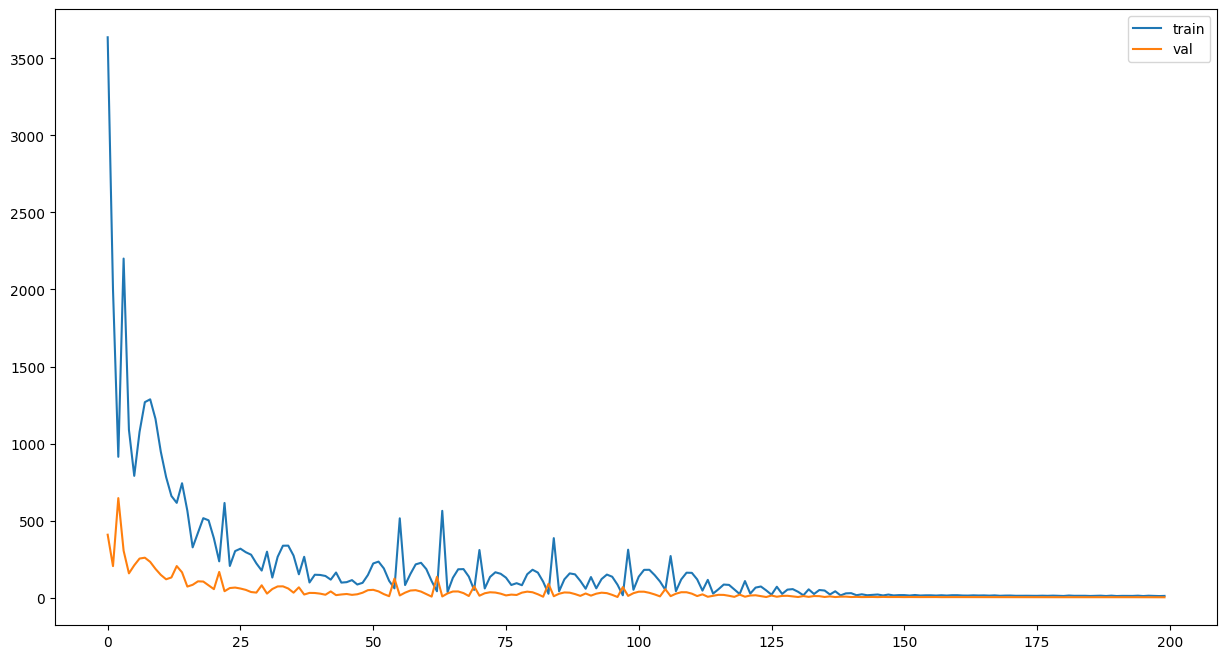

In [35]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(200), train_losses, label="train")
axs.plot(range(200), val_losses, label="val")
axs.legend()

In [34]:
# Evaluación UNSW_NB15_2
model2.eval()
all_preds, all_labels = [], []
roc_auc = 0
accuracy = 0
precision = 0
recall = 0
f1 = 0
with torch.no_grad():
    snapshots_data_test = [(torch_geo_graphs_unsw2[i].x, torch_geo_graphs_unsw2[i].edge_index, torch_geo_graphs_unsw2[i].edge_attr) for i in range(len(torch_geo_graphs_unsw2))]
    edge_labels_test = [torch_geo_graphs_unsw2[i].y for i in range(len(torch_geo_graphs_unsw2))]

    edge_predictions, _ = model2(snapshots_data_test)

    probabilities = [torch.sigmoid(edge_pred) for edge_pred in edge_predictions] # Apply sigmoid to get probabilities
    # Convert probabilities to binary predictions using a threshold
    preds = [(probabilities[i].view(-1) > 0.5).long() for i in range(len(probabilities))]  # Thresholding at 0.5
    #preds = torch.sigmoid(out).cpu().numpy()

    all_preds.extend(preds)
    all_labels.extend(edge_labels_test)#data.y.cpu().numpy())

# Metrics
for i in range(len(all_preds)):
    roc_auc += roc_auc_score(all_labels[i], all_preds[i])
    accuracy += accuracy_score(all_labels[i], all_preds[i])
    precision += precision_score(all_labels[i], all_preds[i], average='binary', zero_division=0)  # Use 'binary' for binary classification
    recall += recall_score(all_labels[i], all_preds[i], average='binary', zero_division=0)
    f1 += f1_score(all_labels[i], all_preds[i], average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc/len(all_preds):.4f}")
print(f"Accuracy: {accuracy/len(all_preds):.4f}")
print(f"Precision: {precision/len(all_preds):.4f}")
print(f"Recall: {recall/len(all_preds):.4f}")
print(f"F1: {f1/len(all_preds):.4f}")


ROC-AUC: 0.8967
Accuracy: 0.8763
Precision: 0.6906
Recall: 0.9375
F1: 0.7934


## Model 3

In [48]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

#num_snapshots = 39
node_feature_dim = 1
edge_feature_dim = 5
hidden_dim = 16
batch_size = 2

train_windows = list(range(30))
val_windows = list(range(30,39))


model3 = GraphRNNWithAttention(node_feature_dim, edge_feature_dim, hidden_dim)
optimizer = torch.optim.Adam(model3.parameters(), lr=0.01)
#loss_fn = nn.CrossEntropyLoss()

ratio_neg_to_pos = 2.5
pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Train
epochs = 200
train_losses = []
val_losses = []

for epoch in range(epochs):
    # ===== Training =====
    model3.train()
    total_loss = 0
    optimizer.zero_grad()

    snapshots_data = [(torch_geo_graphs_unsw1[i].x, torch_geo_graphs_unsw1[i].edge_index, torch_geo_graphs_unsw1[i].edge_attr) for i in train_windows]
    edge_labels = [torch_geo_graphs_unsw1[i].y for i in train_windows]

    edge_predictions, _ = model3(snapshots_data)

    # Calcular pérdida
    loss = sum(
        loss_fn(edge_pred.squeeze(), edge_label.float())
        for edge_pred, edge_label in zip(edge_predictions, edge_labels)
    )
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
    train_losses.append(total_loss)

    # ===== Validation =====
    model3.eval()
    val_loss = 0
    with torch.no_grad():
        val_snapshots_data = [(torch_geo_graphs_unsw1[i].x, torch_geo_graphs_unsw1[i].edge_index, torch_geo_graphs_unsw1[i].edge_attr) for i in val_windows]
        val_edge_labels = [torch_geo_graphs_unsw1[i].y for i in val_windows]

        val_edge_predictions, _ = model3(val_snapshots_data)

        val_loss = sum(
            loss_fn(edge_pred.squeeze(), edge_label.float())
            for edge_pred, edge_label in zip(val_edge_predictions, val_edge_labels)
        )
    val_losses.append(val_loss.item())

    # Mostrar métricas por época
    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {total_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch 1/200, Train Loss: 1946.3740, Val Loss: 224.8428
Epoch 2/200, Train Loss: 1122.8790, Val Loss: 234.0737
Epoch 3/200, Train Loss: 847.6003, Val Loss: 243.7528
Epoch 4/200, Train Loss: 802.7099, Val Loss: 111.9811
Epoch 5/200, Train Loss: 470.1484, Val Loss: 72.7109
Epoch 6/200, Train Loss: 375.8469, Val Loss: 72.3150
Epoch 7/200, Train Loss: 347.6245, Val Loss: 68.8570
Epoch 8/200, Train Loss: 322.0515, Val Loss: 56.0028
Epoch 9/200, Train Loss: 249.9145, Val Loss: 34.8982
Epoch 10/200, Train Loss: 140.6833, Val Loss: 22.9860
Epoch 11/200, Train Loss: 105.3536, Val Loss: 26.1566
Epoch 12/200, Train Loss: 124.4341, Val Loss: 23.1984
Epoch 13/200, Train Loss: 75.8823, Val Loss: 30.9789
Epoch 14/200, Train Loss: 100.0866, Val Loss: 34.2781
Epoch 15/200, Train Loss: 117.0067, Val Loss: 32.2118
Epoch 16/200, Train Loss: 106.7205, Val Loss: 26.5675
Epoch 17/200, Train Loss: 81.8624, Val Loss: 24.6895
Epoch 18/200, Train Loss: 85.4246, Val Loss: 26.1410
Epoch 19/200, Train Loss: 109.5979

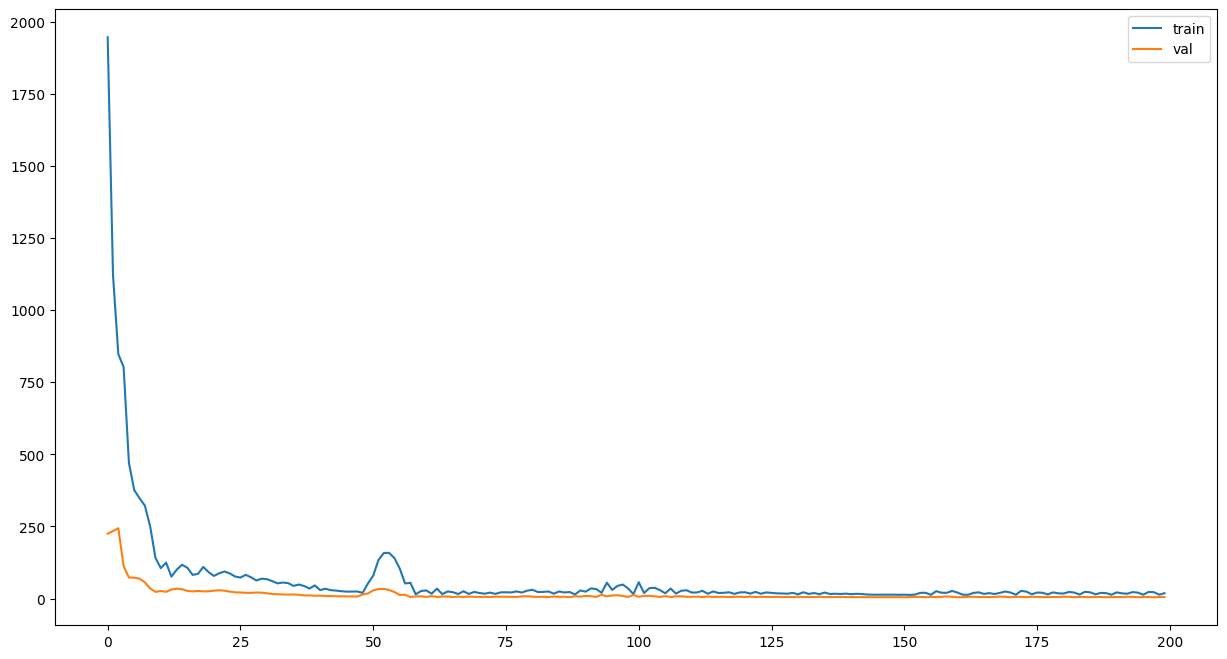

In [49]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(200), train_losses, label="train")
axs.plot(range(200), val_losses, label="val")
axs.legend()

In [53]:
# Evaluación UNSW_NB15_2
model3.eval()
all_preds, all_labels = [], []
roc_auc = 0
accuracy = 0
precision = 0
recall = 0
f1 = 0
with torch.no_grad():
    snapshots_data_test = [(torch_geo_graphs_unsw2[i].x, torch_geo_graphs_unsw2[i].edge_index, torch_geo_graphs_unsw2[i].edge_attr) for i in range(len(torch_geo_graphs_unsw2))]
    edge_labels_test = [torch_geo_graphs_unsw2[i].y for i in range(len(torch_geo_graphs_unsw2))]

    edge_predictions, _ = model3(snapshots_data_test)

    probabilities = [torch.sigmoid(edge_pred) for edge_pred in edge_predictions] # Apply sigmoid to get probabilities
    # Convert probabilities to binary predictions using a threshold
    preds = [(probabilities[i].view(-1) > 0.5).long() for i in range(len(probabilities))]  # Thresholding at 0.5
    #preds = torch.sigmoid(out).cpu().numpy()

    all_preds.extend(preds)
    all_labels.extend(edge_labels_test)#data.y.cpu().numpy())

# Metrics
for i in range(len(all_preds)):
    roc_auc += roc_auc_score(all_labels[i], all_preds[i])
    accuracy += accuracy_score(all_labels[i], all_preds[i])
    precision += precision_score(all_labels[i], all_preds[i], average='binary', zero_division=0)  # Use 'binary' for binary classification
    recall += recall_score(all_labels[i], all_preds[i], average='binary', zero_division=0)
    f1 += f1_score(all_labels[i], all_preds[i], average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc/len(all_preds):.4f}")
print(f"Accuracy: {accuracy/len(all_preds):.4f}")
print(f"Precision: {precision/len(all_preds):.4f}")
print(f"Recall: {recall/len(all_preds):.4f}")
print(f"F1: {f1/len(all_preds):.4f}")

ROC-AUC: 0.8790
Accuracy: 0.8715
Precision: 0.6927
Recall: 0.8938
F1: 0.7785
